## Контрольная работа 4 Вариант 9

### Задача 1 Численное дифференцирование (1.5 балла)

Для заданной функции $e^x$ на интервале $[0 ; 2]$:

- Реализовать расчёт аппроксимации производной при заданном шаге $h$ двумя методами с первым и вторым порядком аппроксимации. Граничные точки должны вычисляться с тем же порядком аппроксимации.
- Построить графики ошибки вычисления от $n$ - числа подряд взятий производной вашими методами (как известно, $\frac{d e^x}{dx}=e^x$)
- Повторите предыдущий пункт для $e^{2x}$

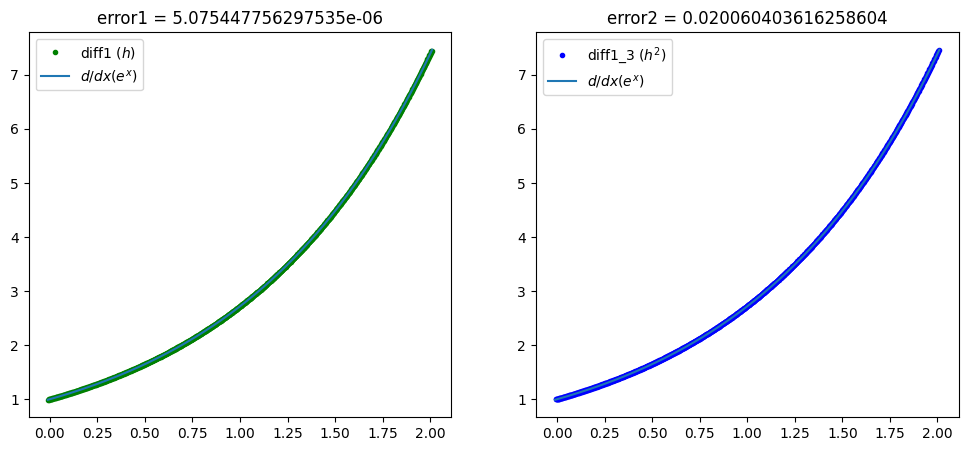

In [17]:
import numpy as np
import matplotlib.pyplot as plt

delta = 0.01
t = np.linspace(0-delta, 2+delta, 1000)
h = t[1] - t[0]

k = 1
def diff1(t, p):
    return (p[2*k:] - p[:-2*k]) / (t[2*k:] - t[:-2*k])
def diff1_3(t, p):
    return (8*p[4:] - 8*p[2:-2] - p[4:] + p[:-4]) / (12 * h)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
plt.plot(t[2:-2], diff1_3(t, np.exp(t)), 'b.', label="diff1_3 ($h^2$)")
plt.plot(t, np.exp(t), label="$d/dx(e^x)$")
plt.title('error2 = ' + str(np.abs(diff1_3(t, np.exp(t)) - np.exp(t[2:-2])).max()))
plt.legend(loc='best')

plt.subplot(1, 2, 1)
plt.plot(t[1:-1], diff1(t, np.exp(t)), 'g.', label="diff1 ($h$)")
plt.plot(t, np.exp(t), label="$d/dx(e^x)$")
plt.title('error1 = ' + str(np.abs(diff1(t, np.exp(t)) - np.exp(t[1:-1])).max()))
plt.legend(loc='best')

array([0.00000000e+00, 1.96647479e-02, 3.92246694e-02, 5.86800967e-02,
       7.79523886e-02, 1.61961508e-01, 4.32956247e+01, 2.70181608e+04,
       1.74692978e+07, 1.09179500e+10, 6.91914317e+12, 4.54132780e+15])

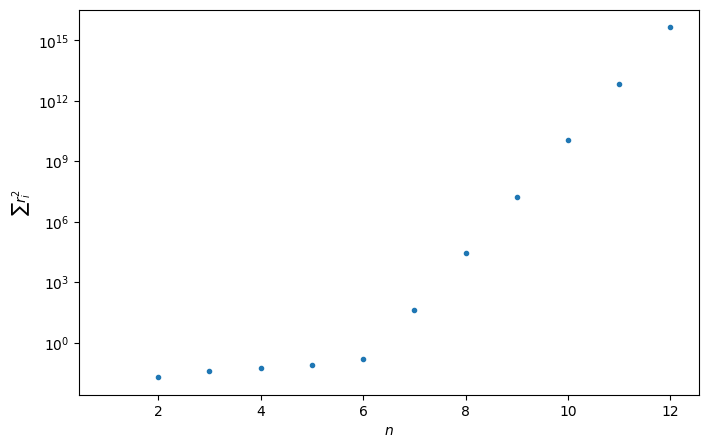

In [82]:
# ошибка от n
t = np.linspace(0, 2, 1000)
h = t[1] - t[0]
def diff1_3(t, p):
    return (8*p[4:] - 8*p[2:-2] - p[4:] + p[:-4]) / (12 * h)

nn = np.arange(0, 12, 1)
err = np.zeros(np.size(nn))
y = np.exp(t)

for i in range(1, np.size(nn)):
    err[i] = np.abs(diff1_3(t, y) - np.exp(t[2*i:-2*i])).max()
    y = diff1_3(t, y)

plt.figure(figsize=(8, 5))
plt.semilogy(nn+1, err, '.')
plt.xlabel('$n$')
plt.ylabel('$\sum r_i^2$')
#plt.legend(loc='best')
err

In [83]:
# #np.abs(diff1_3(t, y) - np.exp(t[2:-2])).max()
# np.size(diff1_3(t, y))
# for i in range(10):
#     a = 2*i
#     print(np.size(np.exp(t[2*i:-2*i])))

array([0.00000000e+00, 5.47421480e+01, 1.63497572e+02, 3.79994671e+02,
       8.11402178e+02, 1.67068936e+03, 3.91723368e+03, 3.70425664e+05,
       2.37998698e+08, 1.49696795e+11, 8.84696247e+13, 5.07663477e+16])

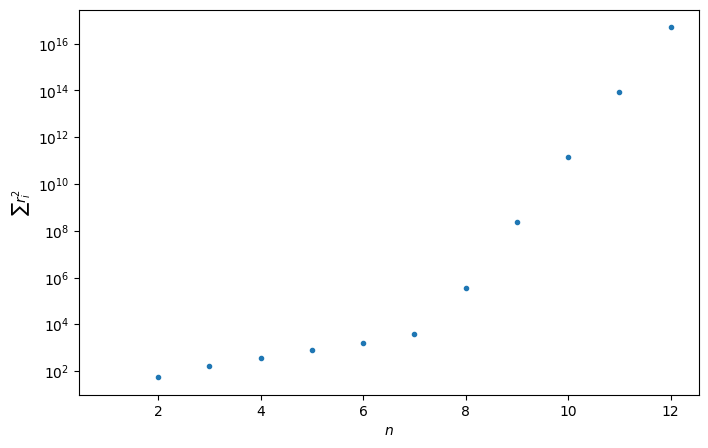

In [84]:
# для 2x
t = np.linspace(0, 2, 1000)
h = t[1] - t[0]
def diff1_3(t, p):
    return (8*p[4:] - 8*p[2:-2] - p[4:] + p[:-4]) / (12 * h)

def f(x):
    return np.exp(2*x)

nn = np.arange(0, 12, 1)
err = np.zeros(np.size(nn))
y = f(t)

for i in range(1, np.size(nn)):
    err[i] = np.abs(diff1_3(t, y) - f(t[2*i:-2*i])).max()
    y = diff1_3(t, y)

plt.figure(figsize=(8, 5))
plt.semilogy(nn+1, err, '.')
plt.xlabel('$n$')
plt.ylabel('$\sum r_i^2$')
#plt.legend(loc='best')
err


### Задача 2  Численное интегрирование (4 балла)

Построить первообразную функции

$$
\int_0^x \frac{1}{\sqrt{t+1}}\operatorname{sin}(t^2) d t
$$

в интервале $[0; 2]$ методами прямоугольников, трапеций, Симпсона при одинаковом шаге $h$. Для каждого метода построить "бегущую ошибку по Рунге" (т.е. график ошибки интеграла в каждой точке, в которой считается первообразная).

Text(0.5, 1.0, 'function')

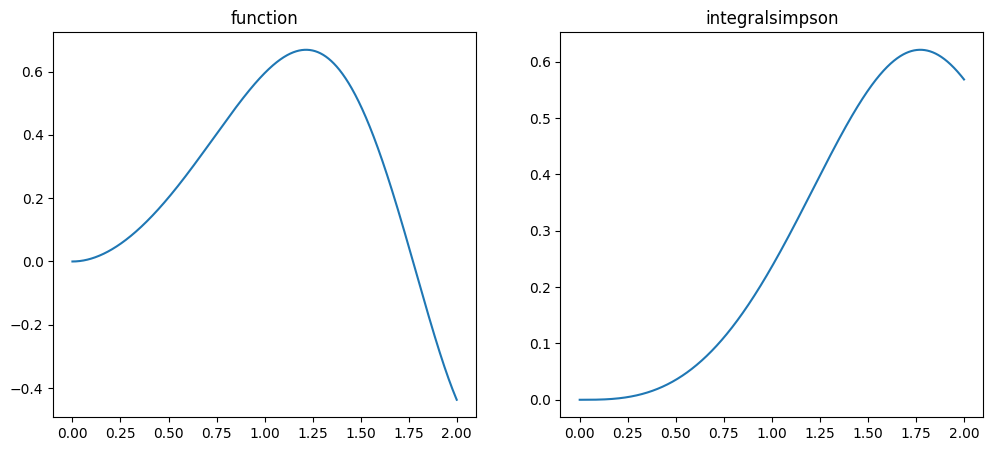

In [102]:
from scipy.integrate import simpson, quad

def f(x):
    return (1/(x+1)**(1/2)) * (np.sin(x**2))

xx = np.linspace(0, 2, 1000)
y = np.array([])

for i in range(np.size(xx)):
    y = np.append(y, simpson(f(xx[0: i+1]), xx[0: i+1]))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
plt.plot(xx, y)
plt.title('integralsimpson')

plt.subplot(1, 2, 1)
plt.plot(xx, f(xx))
plt.title('function')



Text(0.5, 1.0, 'integral')

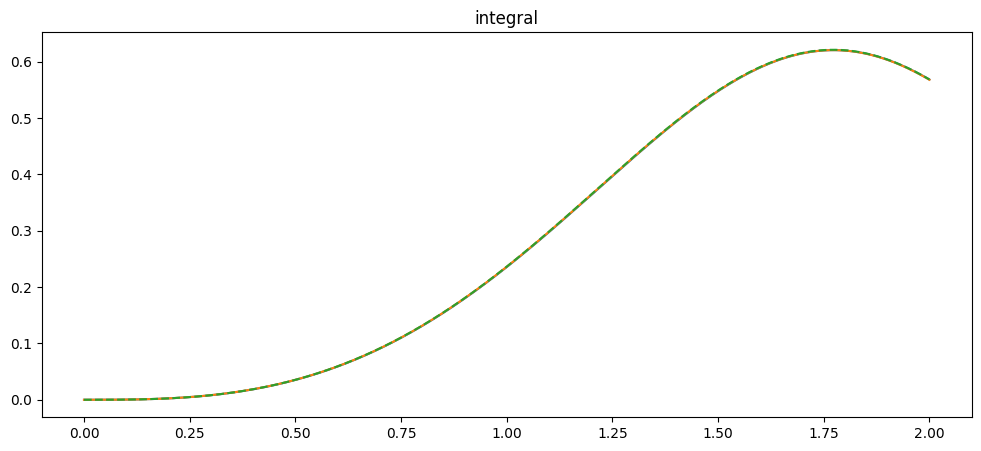

In [104]:
xx = np.linspace(0, 2, 1000)
yR = np.array([])
yT = np.array([])
yS = np.array([])
h = 2/np.size(xx)

def rectangle(f, h):
    return h * np.sum(f[:-1])

def trapezoid(f, h):
    return 0.5 * h * (f[0] + 2 * sum(f[1:-1]) + f[-1])

for i in range(np.size(xx)):
    yR = np.append(yR, rectangle(f(xx[0: i+1]), h))
for i in range(np.size(xx)):
    yT = np.append(yT, trapezoid(f(xx[0: i+1]), h))
for i in range(np.size(xx)):
    yS = np.append(yS, simpson(f(xx[0: i+1]), xx[0: i+1]))


plt.figure(figsize=(12, 5))
plt.plot(xx, yR)
plt.plot(xx, yT)
plt.plot(xx, yS, '--')
plt.title('integral')


Таким образом, погрешность интегрирования на сетке $h/2$ может быть оценена как

$$
I_{h/2} - I^* \approx \frac{I_h - I_{h/2}}{2^p - 1}.
$$

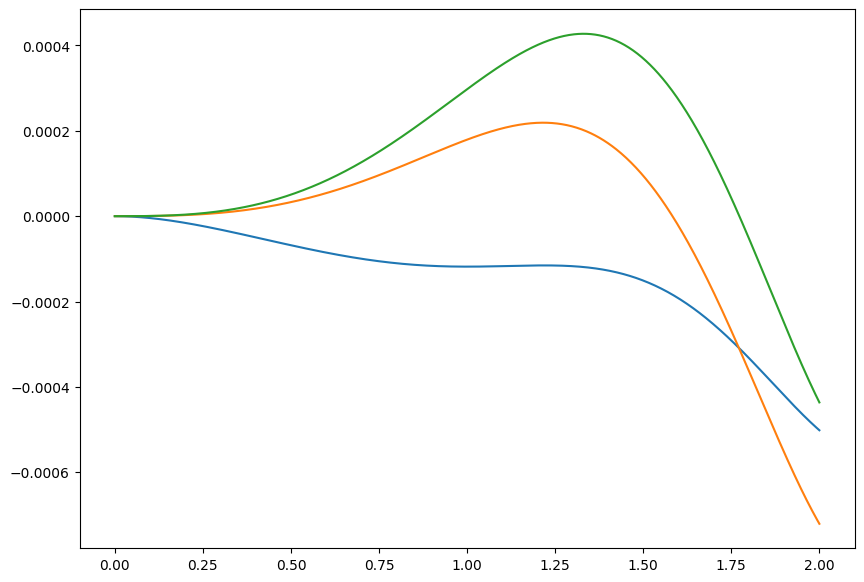

In [ ]:
xx = np.linspace(0, 2, 1000)
xxx = np.linspace(0, 2, 2000)
yR = np.array([])
yT = np.array([])
yS = np.array([])
yR2 = np.array([])
yT2 = np.array([])
yS2 = np.array([])
h = 2/np.size(xx)

for i in range(np.size(xx)):
    yR = np.append(yR, rectangle(f(xx[0: i+1]), h))
    yT = np.append(yT, trapezoid(f(xx[0: i+1]), h))
    yS = np.append(yS, simpson(f(xx[0: i+1]), xx[0: i+1]))

h = 2/np.size(xxx)
for i in range(np.size(xxx)):
    yR2 = np.append(yR2, rectangle(f(xxx[0: i+1]), h))
    yT2 = np.append(yT2, trapezoid(f(xxx[0: i+1]), h))
    yS2 = np.append(yS2, simpson(f(xxx[0: i+1]), xxx[0: i+1]))


errsR = (yR - yR2[::2])/(2**1 - 1)
errsT = (yT - yT2[::2])/(2**2 - 1)
errsS = (yS - yS2[::2])/(2**4 - 1)

    
plt.figure(figsize=(10, 7))
plt.plot(xx, errsR)
plt.plot(xx, errsT)
plt.plot(xx, errsS)

### Задача 3  Интерполяция (2 балла)

Напишите функцию `my_nearest_neighbor(x, y, X)`, где x и y - массивы, содержащие точки экспериментальных данных, а X - массив. Предположим, что x и X расположены в порядке возрастания и имеют уникальные элементы. Выходной аргумент Y должен быть массивом того же размера, что и X, где Y[i] - интерполяция __по ближайшему соседу__ X[i]. То есть Y[i] должен быть равен y[j], где x[j] - ближайшая независимая точка данных X[i]. Нельзя использовать interp1d из scipy. Постройте график интерполяции на каких-нибудь данных, где данная интерполяция сработает хорошо.

### Задача 4  Ряды (1 балл)

Для ряда Лейбница

$$
\sum_{n=1}^{\infty} \frac{(-1)^{n+1}}{n}
$$

оцените ассимптотику сходимости к $\sqrt 2$ от $N$ - количество просуммированных членов ряда. Для точности желательно использовать модуль `Decimal`.


### Задача 5  Дискретное преобразование Фурье (1.5 балла)

Построить графики дискретного преобразования Фурье для

$$
x(k)=\left\{\begin{array}{c}
\cos \left(\frac{2 \pi}{N} k\right) + \mathcal{N}(\sigma, 0), \quad 0 \leq k \leq N-1, \\
0, \quad \text { при других } k .
\end{array}\right.
$$

при $N=128$ и $\sigma$ в промежутке от 0 до 0.5. Как изменяется картина спектра?

$\mathcal{N}(\sigma, 0)$ - гауссов шум с дисперсией $\sigma^2$.
